In [10]:
import os

os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler, OneHotEncoder

from sklearn.impute import SimpleImputer

from sklearn.compose import ColumnTransformer

from sklearn.linear_model import LogisticRegression

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)

from sklearn.svm import SVC

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

from imblearn.pipeline import Pipeline

from imblearn.over_sampling import SMOTE

In [11]:
#charger data
path_raw="../data/raw/rawFile.csv"
df=pd.read_csv(path_raw)
print("********LES DIMENTIONS DE DATA*********")
print(df.shape)
print("********LES CINQUE PREMIERES LIGNES*********")
print(df.head(5))

********LES DIMENTIONS DE DATA*********
(7043, 21)
********LES CINQUE PREMIERES LIGNES*********
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic        

In [12]:
#preparation de data
#render le totalcharge de type numeric
df["TotalCharges"]=pd.to_numeric(df["TotalCharges"],errors="coerce")

#la variable cible
y=df["Churn"].map({"No":0,"Yes":1})

#les variables d'entree
X=df.drop(columns=["Churn", "customerID"],errors="ignore")
print("****** DIMENTIONS DE VARIABLES D'ENTREE ******")
print(X.shape)

print("****** DIMENTIONS DE VARIABLE CIBLE ******")
print(y.shape)

print("****** Distribution de VARIABLE CIBLE ******")
print(y.value_counts())

print("****** Distribution de VARIABLE CIBLE en pourcentage ******")
print( y.value_counts(normalize=True) * 100)


****** DIMENTIONS DE VARIABLES D'ENTREE ******
(7043, 19)
****** DIMENTIONS DE VARIABLE CIBLE ******
(7043,)
****** Distribution de VARIABLE CIBLE ******
Churn
0    5174
1    1869
Name: count, dtype: int64
****** Distribution de VARIABLE CIBLE en pourcentage ******
Churn
0    73.463013
1    26.536987
Name: proportion, dtype: float64


In [13]:
#Train et test split de data
X_train,X_test,y_train,y_test= train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)
print("****** TRAIN et TEST ******")

print("X_train :", X_train.shape)
print("X_test  :", X_test.shape)

print("y_train :", y_train.shape)
print("y_test  :", y_test.shape)

****** TRAIN et TEST ******
X_train : (5634, 19)
X_test  : (1409, 19)
y_train : (5634,)
y_test  : (1409,)


In [14]:
#identification des variables (numeriques et categoricals)
numeric_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns

categorical_features = X_train.select_dtypes(
    include=["object", "category"]
).columns

print("****** Variables numeriques ******")
print(numeric_features)

print("****** Variables categorielles ******")
print(categorical_features)

****** Variables numeriques ******
Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')
****** Variables categorielles ******
Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object')


In [15]:
#preprocessing
numeric_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="median"
            )
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)


categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            )
        ),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)


preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_pipeline,
            numeric_features
        ),
        (
            "cat",
            categorical_pipeline,
            categorical_features
        )
    ]
)


In [16]:
#definition des models

models = {

    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ),

    "Decision Tree": DecisionTreeClassifier(
        class_weight="balanced",
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),
 "SVM": SVC(
        probability=True,
        class_weight="balanced",
        random_state=42
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        random_state=42
    )
}

*****************Logistic Regression*********************
Precision : 0.5034
Recall    : 0.7941
F1-score  : 0.6162
ROC-AUC   : 0.8401
****** Classification Report ******
              precision    recall  f1-score   support

    No Churn       0.91      0.72      0.80      1035
       Churn       0.50      0.79      0.62       374

    accuracy                           0.74      1409
   macro avg       0.70      0.76      0.71      1409
weighted avg       0.80      0.74      0.75      1409

****** Matrice de confusion ******
[[742 293]
 [ 77 297]]


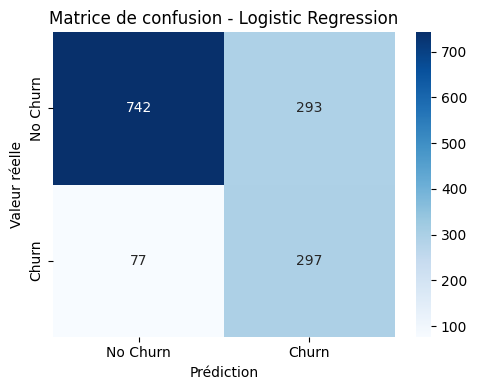

*****************Decision Tree*********************
Precision : 0.4893
Recall    : 0.5481
F1-score  : 0.517
ROC-AUC   : 0.6705
****** Classification Report ******
              precision    recall  f1-score   support

    No Churn       0.83      0.79      0.81      1035
       Churn       0.49      0.55      0.52       374

    accuracy                           0.73      1409
   macro avg       0.66      0.67      0.66      1409
weighted avg       0.74      0.73      0.73      1409

****** Matrice de confusion ******
[[821 214]
 [169 205]]


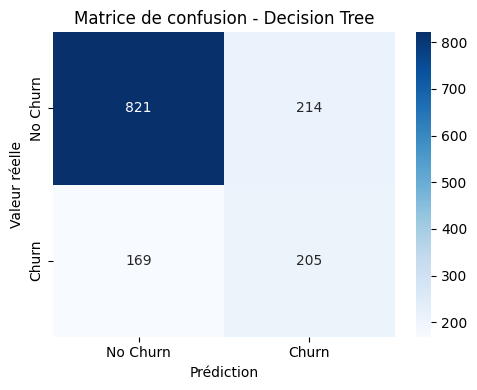

*****************Random Forest*********************
Precision : 0.571
Recall    : 0.5588
F1-score  : 0.5649
ROC-AUC   : 0.8173
****** Classification Report ******
              precision    recall  f1-score   support

    No Churn       0.84      0.85      0.85      1035
       Churn       0.57      0.56      0.56       374

    accuracy                           0.77      1409
   macro avg       0.71      0.70      0.70      1409
weighted avg       0.77      0.77      0.77      1409

****** Matrice de confusion ******
[[878 157]
 [165 209]]


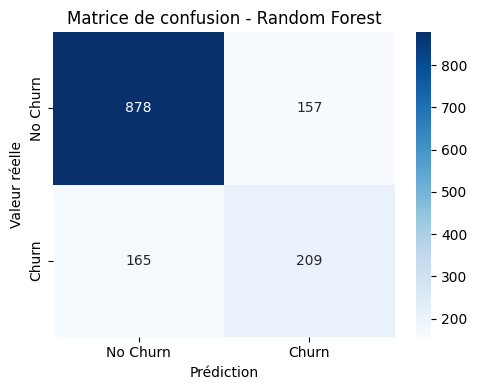

*****************SVM*********************
Precision : 0.5273
Recall    : 0.7219
F1-score  : 0.6095
ROC-AUC   : 0.8212
****** Classification Report ******
              precision    recall  f1-score   support

    No Churn       0.88      0.77      0.82      1035
       Churn       0.53      0.72      0.61       374

    accuracy                           0.75      1409
   macro avg       0.71      0.74      0.72      1409
weighted avg       0.79      0.75      0.76      1409

****** Matrice de confusion ******
[[793 242]
 [104 270]]


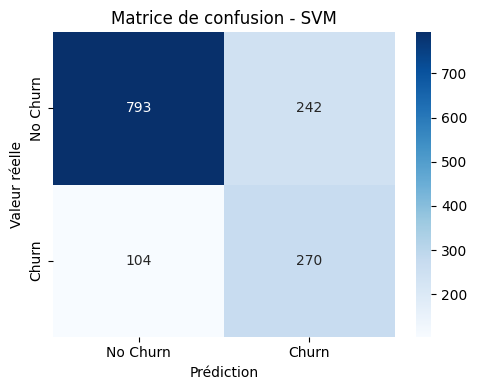

*****************Gradient Boosting*********************
Precision : 0.5575
Recall    : 0.6738
F1-score  : 0.6102
ROC-AUC   : 0.8395
****** Classification Report ******
              precision    recall  f1-score   support

    No Churn       0.87      0.81      0.84      1035
       Churn       0.56      0.67      0.61       374

    accuracy                           0.77      1409
   macro avg       0.72      0.74      0.72      1409
weighted avg       0.79      0.77      0.78      1409

****** Matrice de confusion ******
[[835 200]
 [122 252]]


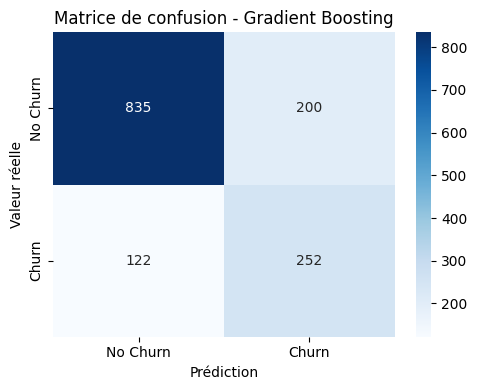

In [17]:
#entrainement des models+ smote

results = []

for model_name, model in models.items():

  
    print(f"*****************{model_name}*********************")

    pipeline = Pipeline(
        steps=[
            (
                "preprocessor",
                preprocessor
            ),
            (
                "smote",
                SMOTE(
                    random_state=42
                )
                
            ),
            (
                "model",
                model
            )
        ]
    )


   


    pipeline.fit(
         X_train,
         y_train
    )

    # Predictions
    y_pred = pipeline.predict(X_test)

    # Probabilités de la classe positive
    y_proba = pipeline.predict_proba(X_test)[:, 1]


    # Metriques
    precision = precision_score(
        y_test,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred,
        zero_division=0
    )

    roc_auc = roc_auc_score(
        y_test,
        y_proba
    )


    # Affichage
    print("Precision :", round(precision, 4))
    print("Recall    :", round(recall, 4))
    print("F1-score  :", round(f1, 4))
    print("ROC-AUC   :", round(roc_auc, 4))

    print("****** Classification Report ******")

    print(
        classification_report(
            y_test,
            y_pred,
            target_names=["No Churn", "Churn"],
            zero_division=0
        )
    )


    # Matrice de confusion
    cm = confusion_matrix(
        y_test,
        y_pred
    )

    print("****** Matrice de confusion ******")
    print(cm)


    # Graphique matrice de confusion
    plt.figure(figsize=(5, 4))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["No Churn", "Churn"],
        yticklabels=["No Churn", "Churn"]
    )

    plt.xlabel("Prédiction")
    plt.ylabel("Valeur réelle")

    plt.title(
        f"Matrice de confusion - {model_name}"
    )

    plt.tight_layout()
    plt.show()


    # Sauvegarde des resultats
    results.append({
        "Model": model_name,
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1,
        "ROC-AUC": roc_auc
    })



In [18]:
#comparaison final
results_df = pd.DataFrame(results)

print("\n")
print("=" * 60)
print("             COMPARAISON DES MODELES")
print("=" * 60)

print(
    results_df.sort_values(
        by="F1-score",
        ascending=False
    )
)


# Sauvegarder le tableau
results_df.to_csv(
    "../data/processed/classification_results_smote.csv",
    index=False
)

print(
    " classification_results_smote.csv créé avec succès !"
)



             COMPARAISON DES MODELES
                 Model  Precision    Recall  F1-score   ROC-AUC
0  Logistic Regression   0.503390  0.794118  0.616183  0.840071
4    Gradient Boosting   0.557522  0.673797  0.610169  0.839487
3                  SVM   0.527344  0.721925  0.609481  0.821230
2        Random Forest   0.571038  0.558824  0.564865  0.817274
1        Decision Tree   0.489260  0.548128  0.517024  0.670464
 classification_results_smote.csv créé avec succès !
